# **IAPR26: UNO Vision Challenge**


**Group Name :** 

**Author 1 (sciper):** Arno Douady (326395)  
**Author 2 (sciper):** Nicolas Robson (325334)   
**Author 3 (sciper):** Johanne Pinel (324707)   

**Release date:** 24.04.2026   
**Due date:** 20.05.2026 (11:55 pm)


In [1]:
# From past Labs

from skimage.color import rgb2hsv
from skimage.morphology import closing, opening, disk, remove_small_holes, remove_small_objects, binary_dilation
from skimage.transform import rotate, resize, AffineTransform, warp
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops
import matplotlib.image as mpimg


import os
import copy
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from src.Project_utils import *

from sklearn.metrics import accuracy_score, f1_score

In [2]:
# Check dans quel dossier on est
print(os.getcwd())

c:\Users\Johanne\Desktop\EPFL\MA4\Image pattern\iapr2026\Project


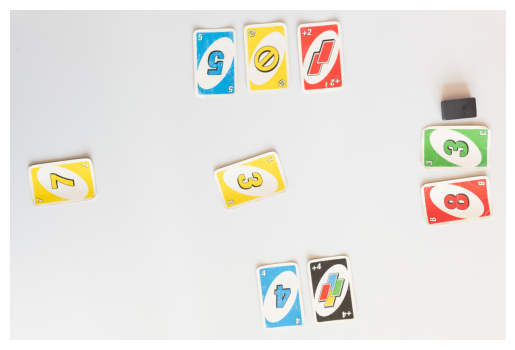

In [7]:
# Printer une image
img = mpimg.imread("data/iapr-26-uno-vision-challenge/train_images/L1000776.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

## Fist step : Segmentation

Extraire les cartes --> hmmm peut être faire 5 images : une pour le jaune, une pour le rouge, une pour le bleu et une pour le vert et une dernière pour le noir ?

In [8]:
def extract_hsv_channels(img):
    """
    Extract HSV channels from the input image.

    """
    # Get the shape of the input image
    M, N, C = np.shape(img)

    # Define default values for HSV channels
    data_h = np.zeros((M, N))
    data_s = np.zeros((M, N))
    data_v = np.zeros((M, N))

    data_hsv = rgb2hsv(img)
    data_h = data_hsv[:, :, 0]
    data_s = data_hsv[:, :, 1]
    data_v = data_hsv[:, :, 2]

    return data_h, data_s, data_v

In [9]:
def apply_hsv_threshold(img, h_thresh=0.01, s_thresh=0.1, v_thresh=0.1):
    """
    Apply threshold to the input image in hsv colorspace.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    h_thresh: float
        Hue value threshold
    s_thresh: float
        Saturation value threshold
    v_thresh: float
        Value threshold
    
    Return
    ------
    img_th: np.ndarray (M, N)
        Thresholded image.
    """

    # Define the default value for the input image
    M, N, C = np.shape(img)
    img_th = np.zeros((M, N))

    # Use the previous function to extract HSV channels
    data_h, data_s, data_v = extract_hsv_channels(img=img)
    
    img_th = (data_h > h_thresh) & (data_s > s_thresh) & (data_v > v_thresh)
    
    return  img_th

    

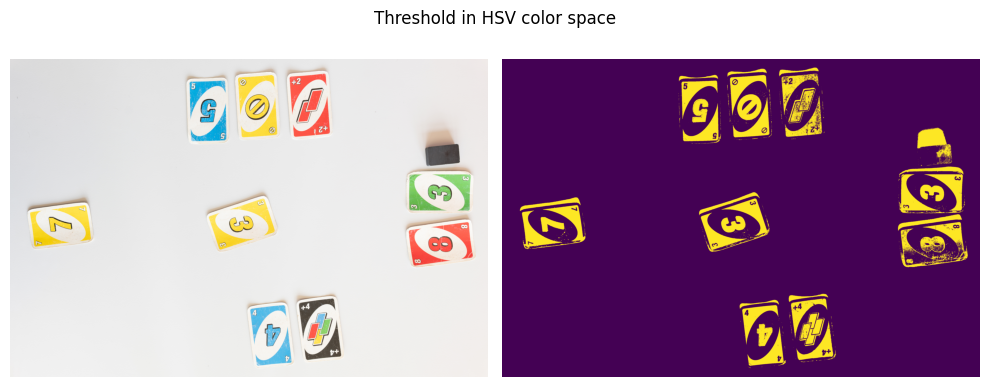

In [10]:
img_th=apply_hsv_threshold(img)
plot_thresholded_image(img=img, func=apply_hsv_threshold, title="Threshold in HSV color space")

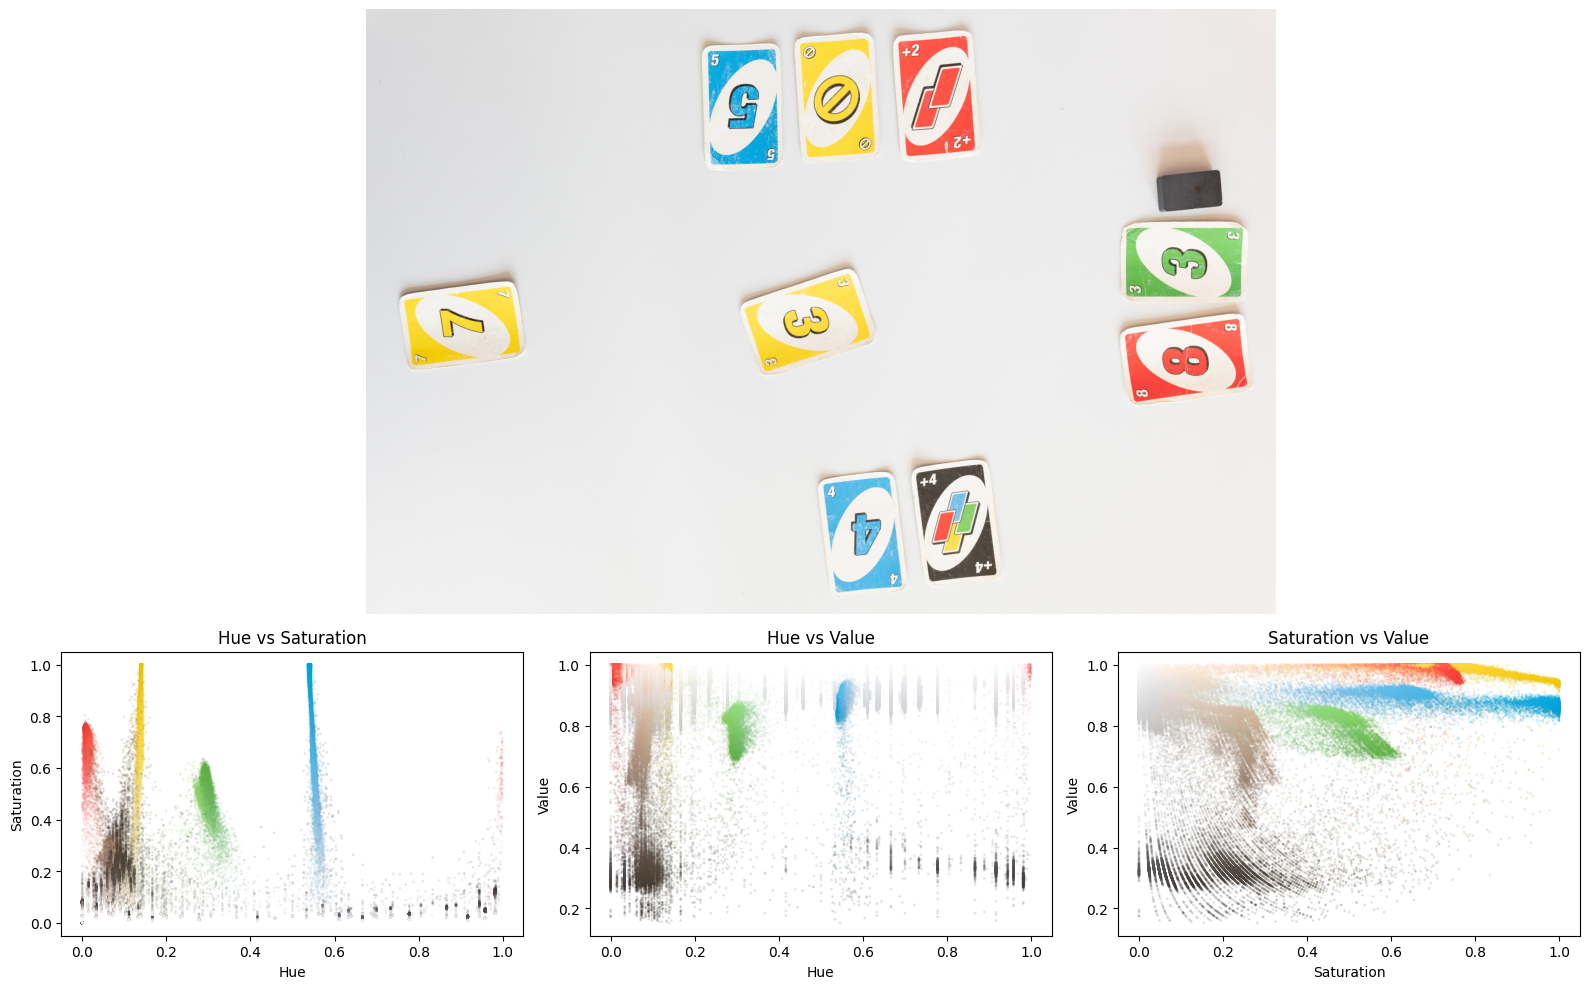

In [11]:
plot_colors_histo(
    img = img,
    func = extract_hsv_channels,
    labels = ["Hue", "Saturation", "Value"],
)
# warning : long à run, environ 1min20s

### Faire comme dernier exo du lab 1 pour décomposer les différents éléments

Est-ce que avoir le channel en noir --> avoir direct la position du joueur/joueuse ?


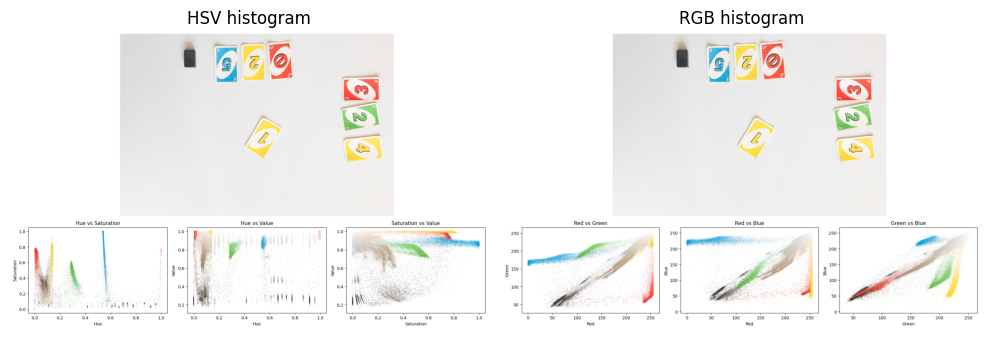

In [12]:
img1 = mpimg.imread("Rapport/output_HSV.png")
img2 = mpimg.imread("Rapport/output_RGB.png")

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img1)
axes[0].axis("off")
axes[0].set_title("HSV histogram")

axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("RGB histogram")

plt.tight_layout()
plt.show()

Du coup pour la segmentation : choix RGB ou HSV --> on voit que c'est beaucoup mieux HSV pour décomposer les couleurs GO faire ça

In [13]:
def remove_objects(img_th, size):

    img_obj = np.zeros_like(img_th)
    img_obj = remove_small_objects(img_th, min_size=size)

    return img_obj

def apply_closing(img_th, disk_size):

    img_closing = np.zeros_like(img_th)
    img_closing = closing(img_th, disk(disk_size))

    return img_closing

def apply_opening(img_th, disk_size):

    img_opening = np.zeros_like(img_th)

    img_opening = opening(img_th, disk(disk_size))

    return img_opening



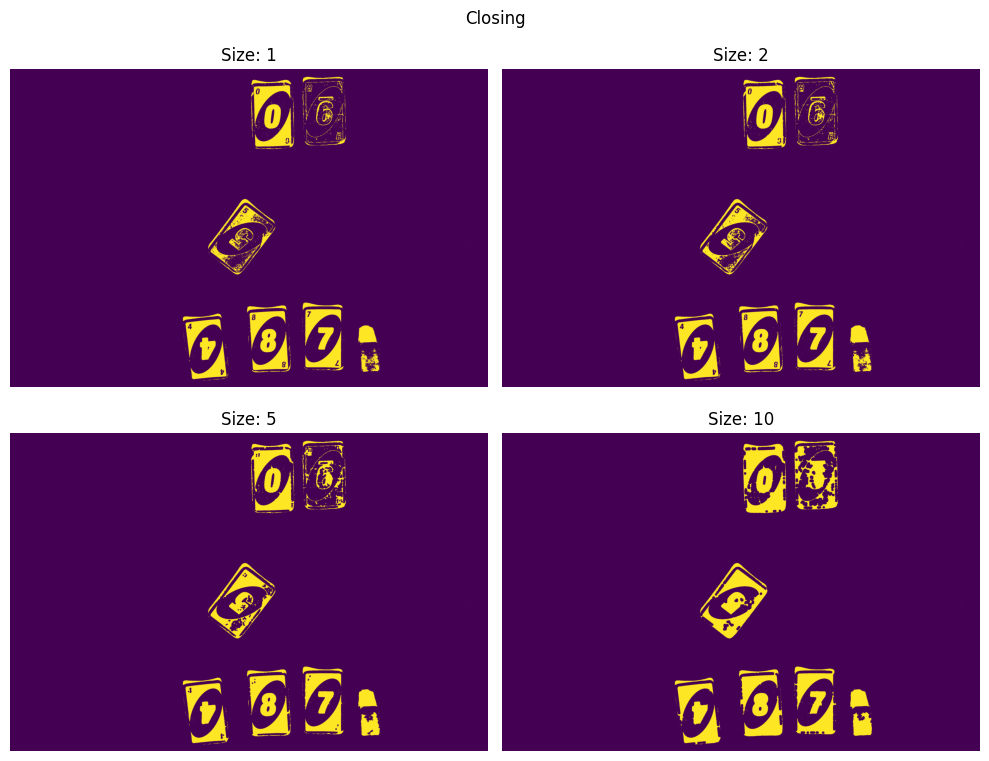

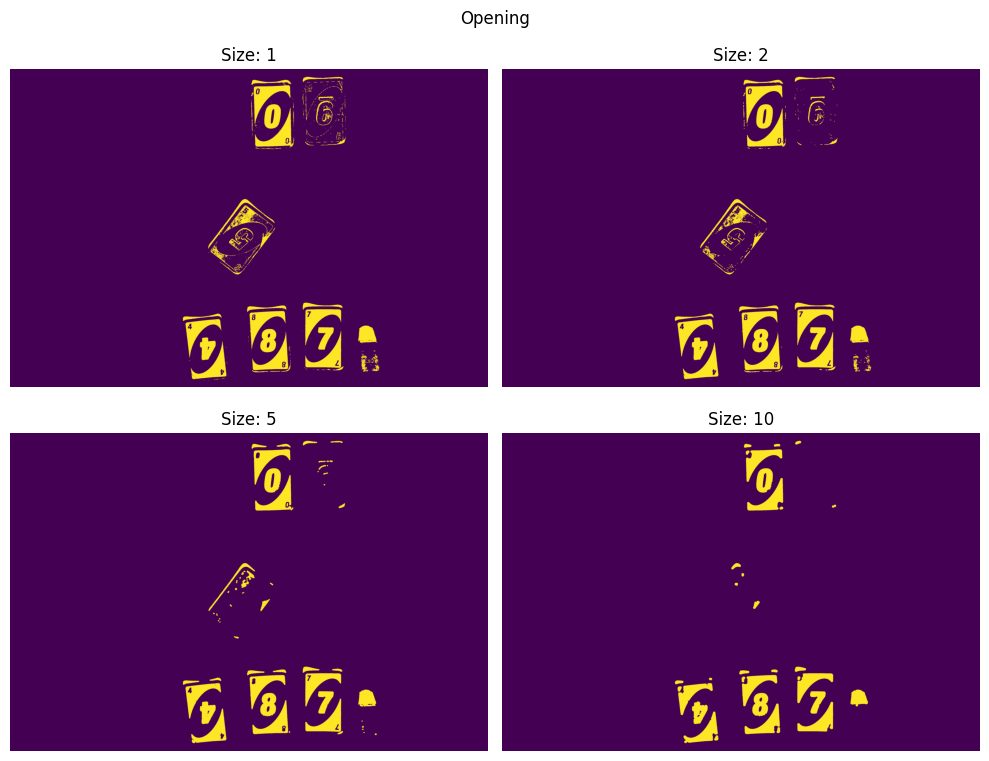

In [9]:
plot_close_open(img_th, apply_closing, apply_opening)

Toutes les étapes avant en une cellule



In [14]:
def apply_hsv_threshold_v2(img, mode="red"):

    M, N, C = np.shape(img)

    data_h, data_s, data_v = extract_hsv_channels(img=img)

    if mode == "red":
        h_min1, h_max1 = 0.0, 0.05 # car 2 pics
        h_min2, h_max2 = 0.95, 1.0
        s_min, s_max = 0.4, 1.0
        v_min, v_max = 0.3, 1.0
        img_th = (
            (((data_h >= h_min1) & (data_h <= h_max1)) | 
             ((data_h >= h_min2) & (data_h <= h_max2))) &
            (data_s > s_min) & (data_s < s_max) &
            (data_v > v_min) & (data_v < v_max)
        )
        return img_th

    if mode == "blue":
        h_min, h_max = 0.52, 0.68
        s_min, s_max = 0.3, 1.0
        v_min, v_max = 0.3, 1.0

    if mode == "yellow":
        h_min, h_max = 0.06, 0.20
        s_min, s_max = 0.2, 1.0
        v_min, v_max = 0.8, 1.0

    if mode == "green":
        # Vert : Hue ~0.25-0.45
        h_min, h_max = 0.22, 0.48
        s_min, s_max = 0.3, 1.0
        v_min, v_max = 0.3, 1.0

    if mode == "black":
        h_min, h_max = 0.0, 1.0  
        s_min, s_max = 0.0, 1.0 
        v_min, v_max = 0.0, 0.35  

    img_th = (
        (data_h > h_min) & (data_h < h_max) &
        (data_s > s_min) & (data_s < s_max) &
        (data_v > v_min) & (data_v < v_max)
    )

    return img_th


def find_area_by_type(
    img: np.ndarray,
    mode: str = "red",
    visualize_hsv: bool = False,
    visualize_mask: bool = False,
    disk_size: int = 20,
    object_min_size: int = 30,
):

    if visualize_hsv:
        plot_colors_histo(
            img=img,
            func=extract_hsv_channels,
            labels=["Hue", "Saturation", "Value"],
        )

    img_th = apply_hsv_threshold_v2(img, mode=mode)

    if visualize_mask:
        plot_thresholded_image(
            img=img,
            func=lambda img: apply_hsv_threshold_v2(img, mode=mode),
            title=f"{mode.capitalize()} detection in HSV space"
        )

    out_mask = apply_opening(img_th, disk_size)
    out_mask = apply_closing(out_mask, disk_size)


    #out_mask = remove_small_objects(out_mask, min_size=object_min_size)


    return out_mask

In [15]:
M, N, C= np.shape(img)
mask_red = np.zeros((M, N))
mask_blue = np.zeros((M, N))
mask_green = np.zeros((M, N))
mask_yellow = np.zeros((M, N))
mask_black = np.zeros((M, N))

# Sans plot qui prend du temps

mask_red = apply_hsv_threshold_v2(img, mode="red")
mask_blue = apply_hsv_threshold_v2(img, mode="blue")
mask_green = apply_hsv_threshold_v2(img, mode="green")
mask_yellow = apply_hsv_threshold_v2(img, mode="yellow")
mask_black = apply_hsv_threshold_v2(img, mode="black")

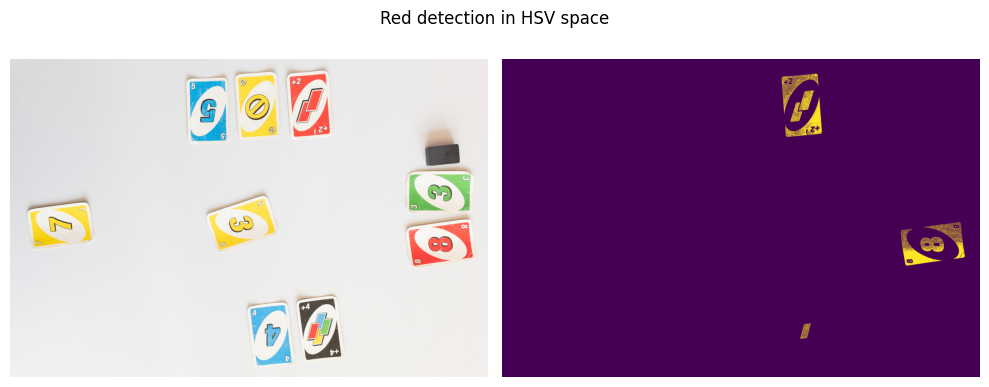

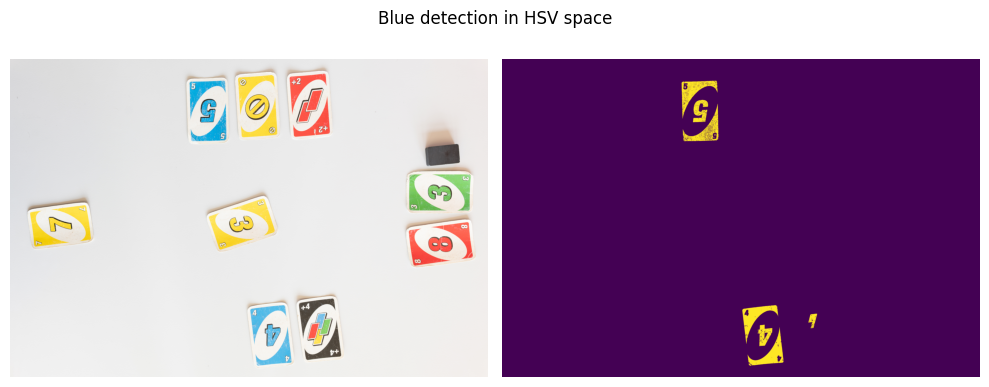

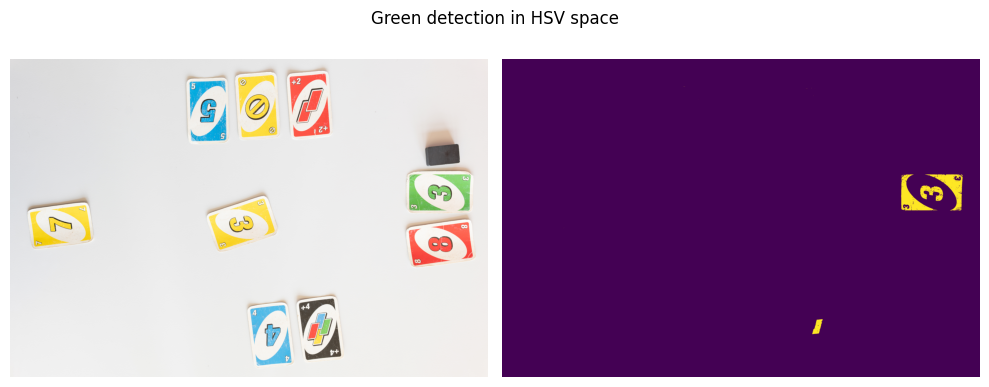

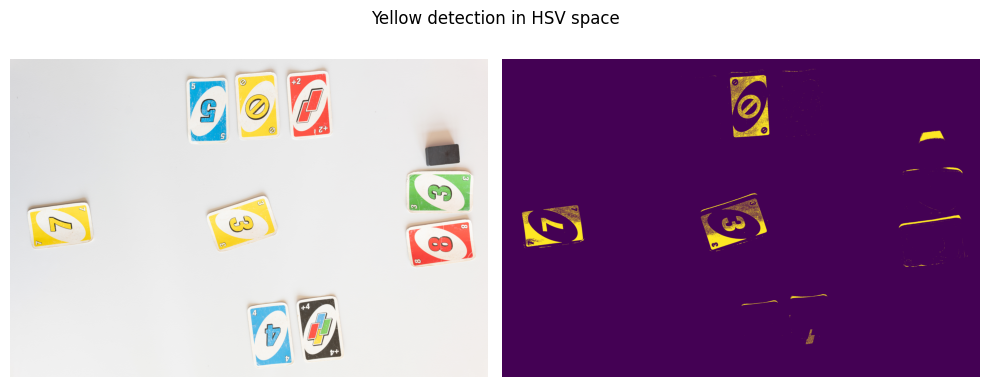

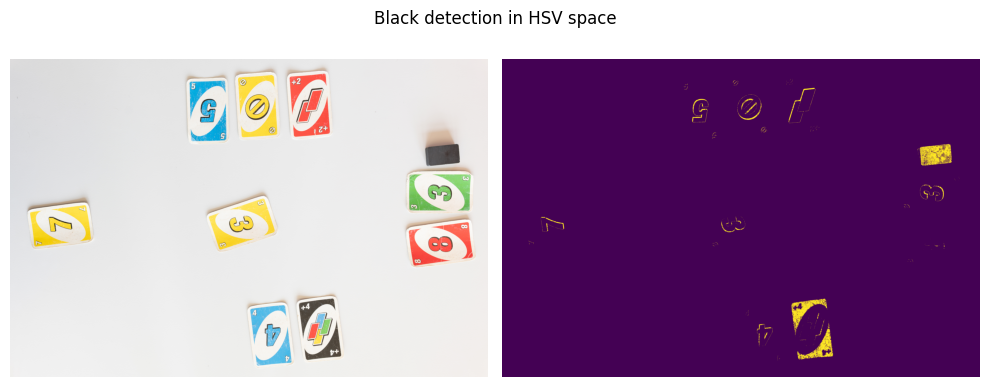

In [16]:
M, N, C= np.shape(img)
mask_red = np.zeros((M, N))
mask_blue = np.zeros((M, N))


mask_red = find_area_by_type(img, mode="red", visualize_mask=True)
mask_blue = find_area_by_type(img, mode="blue", visualize_mask=True)
mask_green = find_area_by_type(img, mode="green", visualize_mask=True)
mask_yellow = find_area_by_type(img, mode="yellow", visualize_mask=True)
mask_black = find_area_by_type(img, mode="black", visualize_mask=True)

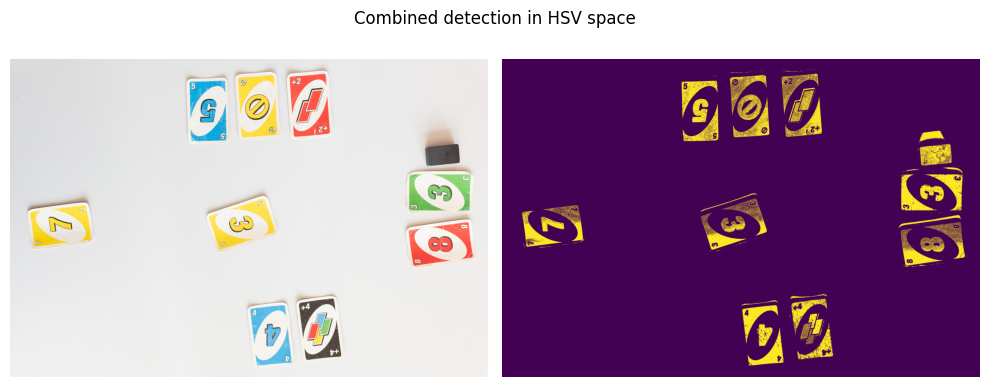

In [19]:
def combined_mask(img, color_masks):

    combined_mask = np.zeros_like(list(color_masks.values())[0])
    for mask in color_masks.values():
        combined_mask = combined_mask | mask
    return combined_mask

color_masks = {
    'red': apply_hsv_threshold_v2(img, mode='red'),
    'blue': apply_hsv_threshold_v2(img, mode='blue'),
    'yellow': apply_hsv_threshold_v2(img, mode='yellow'),
    'green': apply_hsv_threshold_v2(img, mode='green'),
    'black': apply_hsv_threshold_v2(img, mode='black'),
}
final_mask = combined_mask(img, color_masks)

plot_thresholded_image(
            img=img,
            func=lambda img: final_mask,
            title=f"Combined detection in HSV space"
        )


In [20]:
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects, remove_small_holes, closing, disk, opening
import numpy as np
import cv2

def detect_cards_from_masks(masks_dict, min_area=1000, max_area=50000):

    all_cards = []
    
    for color_name, mask in masks_dict.items():


        cleaned_mask = remove_small_objects(mask.astype(bool), min_size=200)
        

        cleaned_mask = remove_small_holes(cleaned_mask, area_threshold=100)
        
        cleaned_mask = closing(cleaned_mask, disk(3))
        
        labeled_mask = label(cleaned_mask)
        
        regions = regionprops(labeled_mask)
        
        for region in regions:
            if min_area < region.area < max_area:
                minr, minc, maxr, maxc = region.bbox
                
                card_info = {
                    'color': color_name,
                    'bbox': (minr, minc, maxr, maxc),  # (y_min, x_min, y_max, x_max)
                    'centroid': region.centroid,  # (y, x)
                    'area': region.area,
                    'orientation': region.orientation,
                    'eccentricity': region.eccentricity,  # Pour vérifier si c'est rectangulaire
                }
                
                all_cards.append(card_info)

            elif 100 < region.area < 50000:
                    print("joueur actif detecté", color_name)

    return all_cards


def classify_by_position(cards, image_shape):

    h, w = image_shape[:2]
    center_y, center_x = h / 2, w / 2
    
    min_dist = float('inf')
    center_card = None
    player_cards_list = []

    
    for card in cards:
        cy, cx = card['centroid']
        dist_to_center = np.sqrt((cy - center_y)**2 + (cx - center_x)**2)

        
        
        if dist_to_center < min(h, w) * 0.15:  # Dans les 15% centraux
            if dist_to_center < min_dist:
                if center_card is not None:
                    player_cards_list.append(center_card)
                center_card = card
                min_dist = dist_to_center
        else:
            player_cards_list.append(card)

   
    player_cards = group_cards_by_player(player_cards_list, image_shape)
    
    return center_card, player_cards


def merge_close_cards(cards, distance_threshold=500):
    merged = []
    used = [False] * len(cards)

    for i in range(len(cards)):
        if used[i]:
            continue

        group = [cards[i]]
        used[i] = True

        cy1, cx1 = cards[i]['centroid']

        for j in range(i + 1, len(cards)):
            if used[j]:
                continue

            cy2, cx2 = cards[j]['centroid']

            dist = np.sqrt((cy1 - cy2)**2 + (cx1 - cx2)**2)

            if dist < distance_threshold:
                group.append(cards[j])
                used[j] = True

        if len(group) == 1:
            merged.append(group[0])
        else:
            mean_cy = np.mean([c['centroid'][0] for c in group])
            mean_cx = np.mean([c['centroid'][1] for c in group])

            minr = min(c['bbox'][0] for c in group)
            minc = min(c['bbox'][1] for c in group)
            maxr = max(c['bbox'][2] for c in group)
            maxc = max(c['bbox'][3] for c in group)

            merged_card = {
                **group[0],
                'centroid': (mean_cy, mean_cx),
                'bbox': (minr, minc, maxr, maxc),
                'area': sum(c['area'] for c in group)
                
            }

            merged.append(merged_card)

    return merged


def group_cards_by_player(cards, image_shape, center_ratio=0.25):
    """
    center_ratio: fraction of image size considered as "center zone"
    """

    if len(cards) == 0:
        return {}

    h, w = image_shape[:2]
    center_y, center_x = h / 2, w / 2

    # size of the "no-player zone"
    center_h = h * center_ratio
    center_w = w * center_ratio

    players = {
        "player_1_bottom": [],
        "player_2_right": [],
        "player_3_top": [],
        "player_4_left": [],
    }

    for card in cards:
        cy, cx = card["centroid"]

        dy = cy - center_y
        dx = cx - center_x

        if abs(dy) < center_h / 2 and abs(dx) < center_w / 2:
            pass

        if abs(dy) > abs(dx):
            if dy > 0:
                players["player_1_bottom"].append(card)
            else:
                players["player_3_top"].append(card)
        else:
            if dx > 0:
                players["player_2_right"].append(card)
            else:
                players["player_4_left"].append(card)

    return players


def main_detection(image, masks_dict):


    all_cards = detect_cards_from_masks(masks_dict)
    all_cards = merge_close_cards(all_cards, distance_threshold=400)

    
    print(f"Nombre total de cartes détectées: {len(all_cards)}")
    
    center_card, player_cards = classify_by_position(all_cards, image.shape)
    
    print(f"Nombre de joueurs: {len([cards for cards in player_cards.values() if cards])}")

    print(f"\nCarte centrale: {center_card['color'] if center_card else 'Non détectée'}")

   
    for player_name, cards in player_cards.items():
        print(f"{player_name}: {len(cards)} cartes - Couleurs: {[c['color'] for c in cards]}")
    
    return center_card, player_cards, all_cards



In [21]:
center_card, player_cards, all_cards = main_detection(img, color_masks)

C:\Users\Johanne\AppData\Local\Temp\ipykernel_6092\1642334638.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mask = remove_small_objects(mask.astype(bool), min_size=200)
C:\Users\Johanne\AppData\Local\Temp\ipykernel_6092\1642334638.py:16: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mas

joueur actif detecté red


C:\Users\Johanne\AppData\Local\Temp\ipykernel_6092\1642334638.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mask = remove_small_objects(mask.astype(bool), min_size=200)
C:\Users\Johanne\AppData\Local\Temp\ipykernel_6092\1642334638.py:16: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mas

joueur actif detecté yellow
joueur actif detecté yellow
joueur actif detecté yellow
joueur actif detecté yellow


C:\Users\Johanne\AppData\Local\Temp\ipykernel_6092\1642334638.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mask = remove_small_objects(mask.astype(bool), min_size=200)
C:\Users\Johanne\AppData\Local\Temp\ipykernel_6092\1642334638.py:16: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mas

joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
Nombre total de cartes détectées: 10
Nombre de joueurs: 4

Carte centrale: yellow
player_1_bottom: 2 cartes - Couleurs: ['red', 'blue']
player_2_right: 3 cartes - Couleurs: ['red', 'yellow', 'green']
player_3_top: 3 cartes - Couleurs: ['red', 'blue', 'yellow']
player_4_left: 1 cartes - Couleurs: ['yellow']


In [29]:
print(f"Shape de l'image: {img.shape}")
print(f"Seuil de distance pour la fusion: {merge_close_cards.__defaults__[0]}")
print("carte à la sortie de merge", merge_close_cards(all_cards, distance_threshold=400))


Shape de l'image: (2662, 4000, 3)
Seuil de distance pour la fusion: 500
carte à la sortie de merge [{'color': 'red', 'bbox': (103, 2475, 615, 2787), 'centroid': (np.float64(316.0007419169933), np.float64(2634.674671414024)), 'area': np.float64(82545.0), 'orientation': -0.9767881576822777, 'eccentricity': 0.8836023805321053}, {'color': 'red', 'bbox': (1143, 1679, 1700, 2199), 'centroid': (np.float64(1405.8452602891343), np.float64(1945.5198980333353)), 'area': np.float64(71274.0), 'orientation': 1.4948507804459843, 'eccentricity': 0.9028171630026137}, {'color': 'yellow', 'bbox': (137, 2041, 649, 2353), 'centroid': (np.float64(400.53447167727245), np.float64(2200.4823668555573)), 'area': np.float64(80797.0), 'orientation': -0.9797612268135414, 'eccentricity': 0.8830474293916174}, {'color': 'yellow', 'bbox': (2302, 2215, 2512, 2327), 'centroid': (np.float64(2395.822263783769), np.float64(2295.8320986074823)), 'area': np.float64(5739.0), 'orientation': -1.3448450249266868, 'eccentricity': 

In [23]:
import matplotlib.patches as patches

def show_detection(image, cards):

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)

    for card in cards:
        cy, cx = card['centroid']
        minr, minc, maxr, maxc = card['bbox']

        ax.plot(cx, cy, 'ro')

        rect = patches.Rectangle(
            (minc, minr),
            maxc - minc,
            maxr - minr,
            linewidth=2,
            edgecolor='lime',
            facecolor='none'
        )
        ax.add_patch(rect)

        # label couleur
        if 'color' in card:
            ax.text(minc, minr - 5, card['color'], color='yellow', fontsize=8)

    ax.set_title(f"{len(cards)} cartes détectées")
    ax.axis('off')
    plt.show()

C:\Users\Johanne\AppData\Local\Temp\ipykernel_6092\1642334638.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mask = remove_small_objects(mask.astype(bool), min_size=200)
C:\Users\Johanne\AppData\Local\Temp\ipykernel_6092\1642334638.py:16: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mas

joueur actif detecté red


C:\Users\Johanne\AppData\Local\Temp\ipykernel_6092\1642334638.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mask = remove_small_objects(mask.astype(bool), min_size=200)
C:\Users\Johanne\AppData\Local\Temp\ipykernel_6092\1642334638.py:16: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mas

joueur actif detecté yellow
joueur actif detecté yellow
joueur actif detecté yellow
joueur actif detecté yellow


C:\Users\Johanne\AppData\Local\Temp\ipykernel_6092\1642334638.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mask = remove_small_objects(mask.astype(bool), min_size=200)
C:\Users\Johanne\AppData\Local\Temp\ipykernel_6092\1642334638.py:16: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mas

joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
joueur actif detecté black
Nombre total de cartes détectées: 10
Nombre de joueurs: 4

Carte centrale: yellow
player_1_bottom: 2 cartes - Couleurs: ['red', 'blue']
player_2_right: 3 cartes - Couleurs: ['red', 'yellow', 'green']
player_3_top: 3 cartes - Couleurs: ['red', 'blue', 'yellow']
player_4_left: 1 cartes - Couleurs: ['yellow']


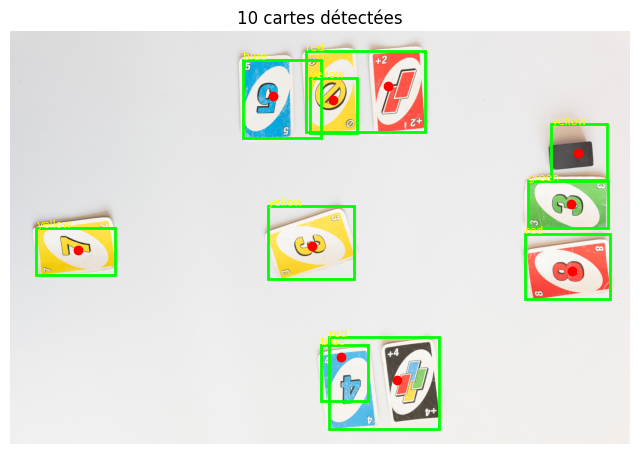

In [24]:
center_card, player_cards, all_cards = main_detection(img, color_masks)

show_detection(img, all_cards)